In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
import os
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Images_Vision")


# Used Flags
| Flag                         | Purpose                            |
| ---------------------------- | ---------------------------------- |
| `DRAW_MATCHES_FLAGS_DEFAULT` | Normal/default drawing             |
| `NOT_DRAW_SINGLE_POINTS`     | Don't draw unmatched keypoints     |
| `DRAW_RICH_KEYPOINTS`        | Show richer keypoint information   |
| `DRAW_OVER_OUTIMG`           | Draw over an existing output image |


# Brute-Force Matching with ORB Descriptors

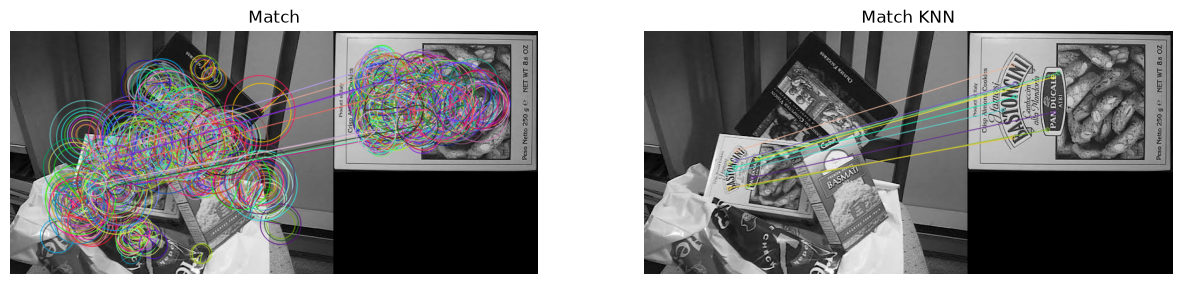

In [27]:
img1=cv2.imread("box.jpg",0)
img2=cv2.imread("box_in_scene.jpg",0)
orb=cv2.ORB_create()
kp1,des1=orb.detectAndCompute(img1,None)
kp2,des2=orb.detectAndCompute(img2,None)
matcher=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=False)
matches1=matcher.match(des1,des2)
matches2=matcher.knnMatch(des1,des2,k=2)
good=[]
for m,n in matches2:
    if m.distance<0.75*n.distance:
        good.append([m])
matches1=sorted(matches1,key=lambda x:x.distance)
result1=cv2.drawMatches(img1,kp1,img2,kp2,matches1[:10],None,flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)
result2=cv2.drawMatchesKnn(img1,kp1,img2,kp2,good[:10],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(result1)
plt.title("Match")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(result2)
plt.title("Match KNN")
plt.axis("off")
plt.show()

# Brute-Force Matching with SIFT Descriptors

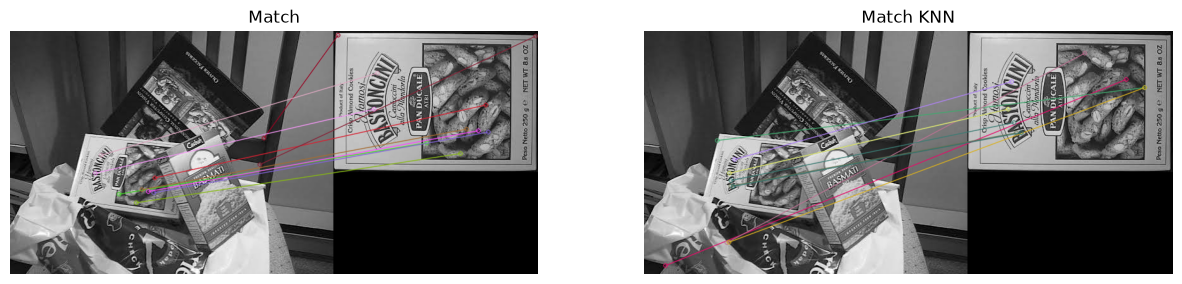

In [29]:
img1=cv2.imread("box.jpg",0)
img2=cv2.imread("box_in_scene.jpg",0)
sift=cv2.SIFT_create()
kp1,des1=sift.detectAndCompute(img1,None)
kp2,des2=sift.detectAndCompute(img2,None)
matcher=cv2.BFMatcher(cv2.NORM_L2,crossCheck=False)
matches1=matcher.match(des1,des2)
matches2=matcher.knnMatch(des1,des2,k=2)
good=[]
for m,n in matches2:
    if m.distance<0.75*n.distance:
        good.append([m])
matches1=sorted(matches1,key=lambda x:x.distance)
result1=cv2.drawMatches(img1,kp1,img2,kp2,matches1[:10],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
result2=cv2.drawMatchesKnn(img1,kp1,img2,kp2,good[:10],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(result1)
plt.title("Match")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(result2)
plt.title("Match KNN")
plt.axis("off")
plt.show()

# FLANN based Matcher

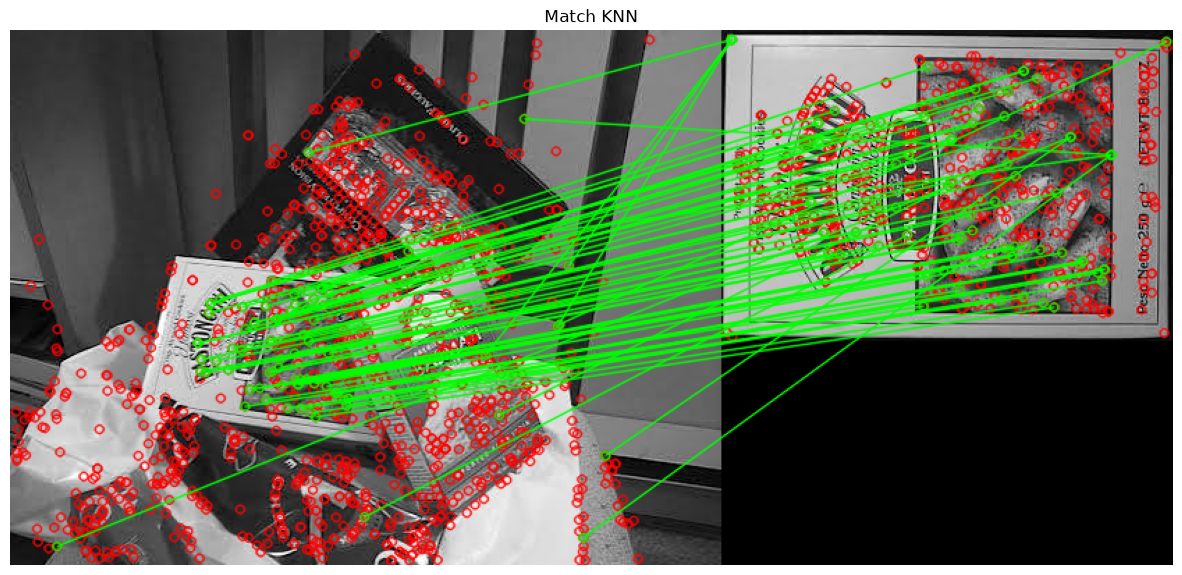

In [25]:
img1=cv2.imread("box.jpg",0)
img2=cv2.imread("box_in_scene.jpg",0)
sift=cv2.SIFT_create()
kp1,des1=sift.detectAndCompute(img1,None)
kp2,des2=sift.detectAndCompute(img2,None)
FLANN_INDEX_KDTREE=1
index_params=dict(algorithm=FLANN_INDEX_KDTREE,trees=5)
search_params=dict(checks=50)
flann=cv2.FlannBasedMatcher(index_params,search_params)
matches=flann.knnMatch(des1,des2,k=2)
matchesMask=[[0,0] for i in range(len(matches))]

for i,(m,n) in enumerate(matches):
    if m.distance < 0.7*n.distance:
        matchesMask[i]=[1,0]
 
draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = (255,0,0),
                   matchesMask = matchesMask,
                   flags = cv2.DrawMatchesFlags_DEFAULT)
result=cv2.drawMatchesKnn(img1,kp1,img2,kp2,matches,None,**draw_params)
plt.figure(figsize=(15,15))
plt.imshow(result)
plt.title("Match KNN")
plt.axis("off")
plt.show()